In [200]:
import numpy as np
from numpy.linalg import norm

def verify_spectral_norm_equality(m, n, num_tests=1000):
    for _ in range(num_tests):
        # Create random matrix C_i with values between 0 and 1
        C_i = np.random.rand(m, n)
        
        # Create C_{i+1} by changing one random column
        C_i1 = C_i.copy()
        col_to_change = np.random.randint(0, n)
        
        # Generate E (the change) as a small fraction of C_i[:, col_to_change]
        E = np.random.rand(m) * 0.6 * C_i[:, col_to_change]
        
        # Update C_i1 to satisfy C_i1[:, col_to_change]^2 + E^2 = C_i[:, col_to_change]^2
        C_i1[:, col_to_change] = np.sqrt(np.maximum(C_i[:, col_to_change]**2 - E**2, 0))
        
        # Calculate the left and right sides of the equality
        C_i_norm = norm(C_i, ord=2)
        C_i1_norm = norm(C_i1, ord=2)
        print(f"Norm difference: {C_i_norm-C_i1_norm}, ratio: {C_i1_norm/C_i_norm}")
        left_side = abs(C_i_norm**2 - C_i1_norm**2)
        right_side = norm(E)**2
        
        # Check if the equality holds (within numerical precision)
        # if not np.isclose(left_side, right_side, rtol=1e-5, atol=1e-8):
        #     print(f"Equality doesn't hold: {left_side} != {right_side}")
        #     print(f"left/right = {left_side/right_side}")
            
            # return False
    
    # print("Equality holds for all test cases!")
    return True

# Set matrix dimensions and number of tests
m, n = 50, 30
num_tests = 10

# Run the verification
verify_spectral_norm_equality(m, n, num_tests)

Norm difference: 0.04690961666800675, ratio: 0.9976036083590615
Equality doesn't hold: 1.8343207795821286 != 2.2691055460426535
left/right = 0.808389359755083
Norm difference: 0.03487078108030062, ratio: 0.9982258031040828
Equality doesn't hold: 1.3695128084465296 != 1.7170553738392387
left/right = 0.7975938512596576
Norm difference: 0.03944280913949072, ratio: 0.997989417350328
Equality doesn't hold: 1.5459908857512232 != 1.8197727830073982
left/right = 0.8495516034679249
Norm difference: 0.0344754260270399, ratio: 0.9982055784651893
Equality doesn't hold: 1.3235336205745512 != 1.5099277462080234
left/right = 0.8765542747978666
Norm difference: 0.042125517716641525, ratio: 0.997850915998173
Equality doesn't hold: 1.6496818206719581 != 2.249069320517603
left/right = 0.733495319874044
Norm difference: 0.04138432386171331, ratio: 0.9978762682382949
Equality doesn't hold: 1.6111673561794078 != 1.9747434883749693
left/right = 0.8158869066611021
Norm difference: 0.04249021067255043, ratio: 

True

In [16]:
import numpy as np

num_tests = 10
for _ in range(num_tests):
    # Generate a random matrix A
    m, n = 5, 4  # Example dimensions, you can change them
    A = np.random.randn(m, n)
    
    # Calculate the theoretical lower bound
    U, _, Vt = np.linalg.svd(A)
    U1 = U[:, 0]  # Leading left singular vector
    
    # Compute the largest singular value of A
    sigma_1_A = np.linalg.norm(A, ord=2)
    
    # Choose a column index to perturb
    j = 2  # Perturb the third column (index 2)
    
    # Generate a perturbation vector u
    u = U1#np.random.randn(m)
    
    # Create the perturbation matrix uv^T
    v = np.zeros(n)
    v[j] = 1  # v is the standard basis vector for the j-th column
    Delta_A = np.outer(u, v)
    # Delta_A = np.outer(u, Vt[0,:])
    k = 0.3
    Delta_A = np.outer(u, k*v + (1-k)*Vt[0,:])
    print(np.linalg.norm(u, ord=2), Delta_A)
    print(A)
    
    # Create the new matrix A' by adding the perturbation
    A_prime = A + Delta_A
    
    # Compute the largest singular value of A'
    sigma_1_A_prime = np.linalg.norm(A_prime, ord=2)
    
    # Calculate the exact change in the largest singular value
    delta_sigma = sigma_1_A_prime - sigma_1_A
    
    print("dot prod:", np.dot(u, U1))
    theoretical_bound = np.abs(np.dot(u, U1)) / sigma_1_A
    
    # Output results
    print(f"Largest singular value of A: {sigma_1_A:.4f}")
    print(f"Largest singular value of A': {sigma_1_A_prime:.4f}")
    print(f"Exact change in largest singular value: {delta_sigma:.4f}")
    print(f"Theoretical lower bound for the change: {theoretical_bound:.4f}")


1.0000000000000002 [[-0.10619484  0.11321731  0.03367809 -0.15179126]
 [-0.11424094  0.12179548  0.03622979 -0.16329207]
 [ 0.03164666 -0.03373939 -0.01003626  0.04523464]
 [ 0.09987378 -0.10647825 -0.03167347  0.14275615]
 [ 0.21332926 -0.22743632 -0.06765416  0.30492551]]
[[-0.96609401  0.82297028  0.19346567 -0.49600725]
 [ 0.61272365  1.1902177   0.54105074 -1.14227724]
 [-0.27614134 -0.92318174 -0.14808282 -0.0500566 ]
 [ 0.02218178 -1.38313035 -0.39967307  0.42322477]
 [ 1.53569425  0.06399304 -1.68025496  1.32042983]]
dot prod: 1.0000000000000004
Largest singular value of A: 3.0635
Largest singular value of A': 3.6055
Exact change in largest singular value: 0.5419
Theoretical lower bound for the change: 0.3264
1.0000000000000007 [[ 0.39421167  0.05316775 -0.26546999  0.17130962]
 [ 0.14985143  0.02021062 -0.10091294  0.06511982]
 [ 0.44536522  0.06006688 -0.29991781  0.19353904]
 [-0.04299851 -0.00579926  0.02895606 -0.01868554]
 [-0.12439421 -0.01677718  0.08376954 -0.05405706]

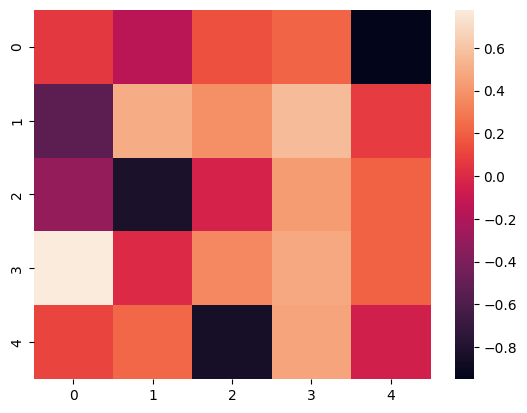

In [3]:
import numpy as np
eps = 1e-6
np.linalg.svd(np.array([[1,0],[eps, 1]]))

SVDResult(U=array([[-0.7071066 , -0.70710696],
       [-0.70710696,  0.7071066 ]]), S=array([1.0000005, 0.9999995]), Vh=array([[-0.70710696, -0.7071066 ],
       [-0.7071066 ,  0.70710696]]))

In [4]:
np.linalg.svd(np.array([[1,0],[0, eps]]))

SVDResult(U=array([[1., 0.],
       [0., 1.]]), S=array([1.e+00, 1.e-06]), Vh=array([[1., 0.],
       [0., 1.]]))

In [14]:
import numpy as np

def givens_rotation(n, i, j, theta):
    """
    Create an n x n Givens rotation matrix for rotating in the (i,j) plane by theta radians.
    """
    G = np.eye(n)
    c, s = np.cos(theta), np.sin(theta)
    G[i, i] = c
    G[j, j] = c
    G[i, j] = -s
    G[j, i] = s
    return G

def create_unitary_matrix(n):
    """
    Create an n x n unitary matrix with a spread-out first column and sparse other columns.
    """
    U = np.eye(n)
    
    # Create the spread-out first column
    for i in range(n-1):
        theta = np.pi / 4
#         theta = np.arccos(np.sqrt((n-i-1)/(n-i)))
        G = givens_rotation(n, i, i+1, theta)
        U = G @ U
        if i == 1:
            break
    
    # Create sparsity in other columns
#     for col in range(1, n):
#         for row in range(col+1, n):
#             if U[row, col] != 0:
#                 # Find a non-zero entry to rotate with
#                 for k in range(col):
#                     if U[row, k] != 0:
#                         theta = np.arctan2(-U[row, col], U[row, k])
#                         G = givens_rotation(n, k, col, theta)
#                         U = U @ G.T  # Note: we apply G.T on the right
#                         break
    
    return U

# Create and display a 5x5 unitary matrix
n = 5
U = create_unitary_matrix(n)

print("Resulting unitary matrix:")
print(np.round(U, decimals=3))

print("\nVerifying unitarity (U * U^H = I):")
print(np.round(U @ U.conj().T, decimals=3))

print("\nColumn magnitudes:")
print(np.round(np.sum(np.abs(U)**2, axis=0), decimals=3))

Resulting unitary matrix:
[[ 0.707 -0.707  0.     0.     0.   ]
 [ 0.5    0.5   -0.707  0.     0.   ]
 [ 0.5    0.5    0.707  0.     0.   ]
 [ 0.     0.     0.     1.     0.   ]
 [ 0.     0.     0.     0.     1.   ]]

Verifying unitarity (U * U^H = I):
[[ 1. -0.  0.  0.  0.]
 [-0.  1.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  1.]]

Column magnitudes:
[1. 1. 1. 1. 1.]


In [15]:
np.cos(np.pi/4) * np.array([np.cos(np.pi/4), np.cos(np.pi/4), 0]) + np.sin(np.pi/4) * np.array([0, 0, 1])

array([0.5       , 0.5       , 0.70710678])

In [5]:
import numpy as np

def householder_vector(x, y):
    """Compute the Householder vector to reflect x onto y."""
    u = x - y
    u_norm = np.linalg.norm(u)
    if u_norm < 1e-10:  # x and y are essentially the same
        return np.zeros_like(x)
    return u / u_norm

def householder_matrix(v):
    """Compute the Householder matrix from a Householder vector."""
    return np.eye(len(v)) - 2 * np.outer(v, v)

def create_unitary_matrix(n, sparsity_pattern):
    """
    Create an n x n unitary matrix with a spread-out first column and specified sparsity.
    
    :param n: Size of the matrix
    :param sparsity_pattern: List of lists specifying desired non-zero entries for columns 2 to n
    :return: Unitary matrix
    """
    # Start with the identity matrix
    U = np.eye(n)
    
    # Create the spread-out column
    e1 = np.zeros(n)
    e1[0] = 1
    v_spread = np.ones(n) / np.sqrt(n)
    h_vector = householder_vector(e1, v_spread)
    H = householder_matrix(h_vector)
    U = H @ U
    
    # Create sparsity in other columns
    for col in range(1, n):
        target = np.zeros(n)
        for row in sparsity_pattern[col-1]:
            target[row] = 1  # We'll normalize later
        target = target / np.linalg.norm(target)
        
        current = U[:, col]
        h_vector = householder_vector(current, target)
        H = householder_matrix(h_vector)
        U = H @ U
    
    return U

# Example usage
n = 5
sparsity_pattern = [
    [0, 1],    # Column 2: non-zero in rows 0 and 1
    [1, 2],    # Column 3: non-zero in rows 1 and 2
    [2, 3],    # Column 4: non-zero in rows 2 and 3
    [3, 4]     # Column 5: non-zero in rows 3 and 4
]

U = create_unitary_matrix(n, sparsity_pattern)

print("Resulting unitary matrix:")
print(np.round(U, 3))

print("\nVerifying unitarity (U * U^H = I):")
print(np.round(U @ U.conj().T, 3))

print("\nColumn magnitudes:")
print(np.round(np.linalg.norm(U, axis=0), 3))

Resulting unitary matrix:
[[-0.543  0.832  0.097  0.057 -0.   ]
 [-0.046 -0.154  0.974  0.157 -0.   ]
 [ 0.305  0.148 -0.112  0.934 -0.   ]
 [ 0.553  0.361  0.119 -0.223  0.707]
 [-0.553 -0.361 -0.119  0.223  0.707]]

Verifying unitarity (U * U^H = I):
[[ 1. -0. -0. -0.  0.]
 [-0.  1.  0.  0.  0.]
 [-0.  0.  1. -0. -0.]
 [-0.  0. -0.  1. -0.]
 [ 0.  0. -0. -0.  1.]]

Column magnitudes:
[1. 1. 1. 1. 1.]


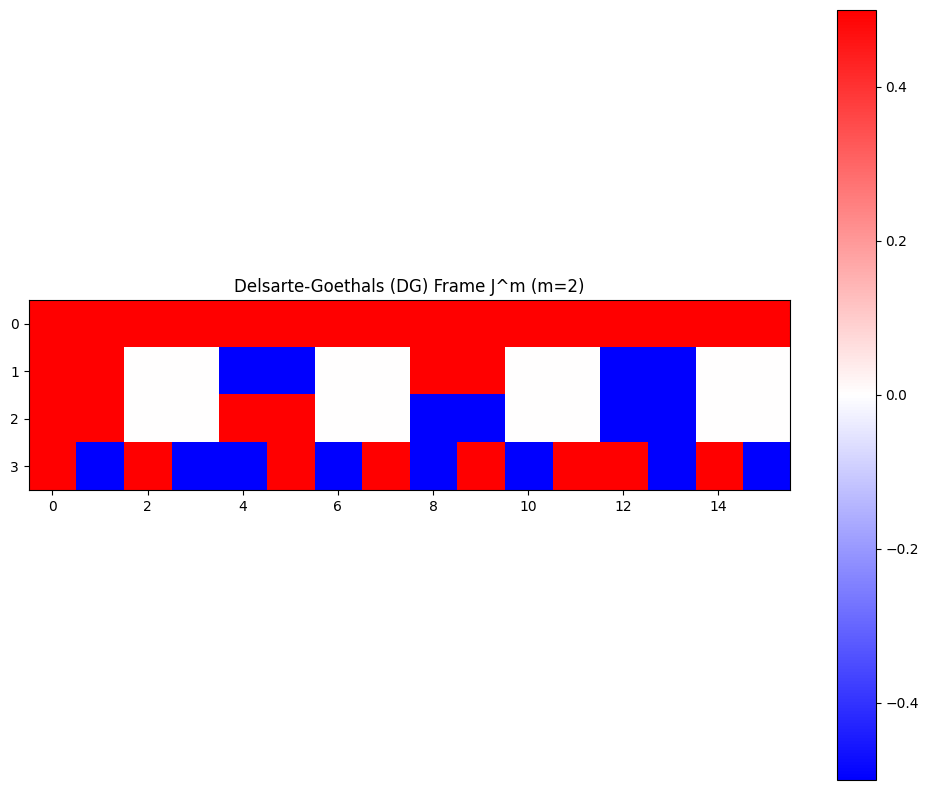

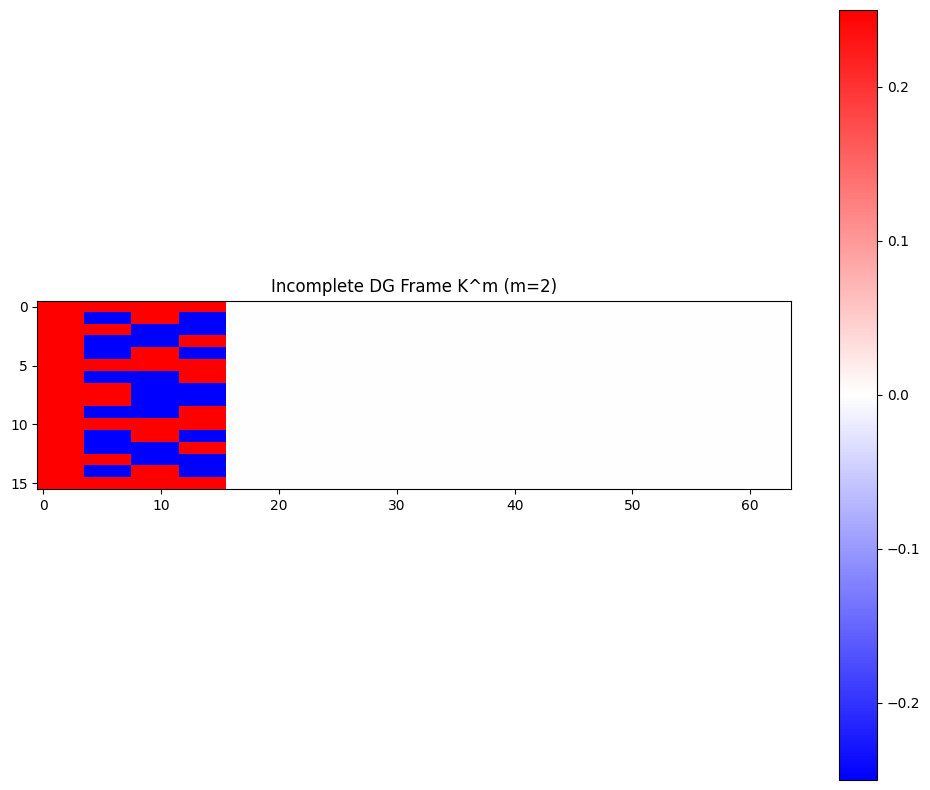

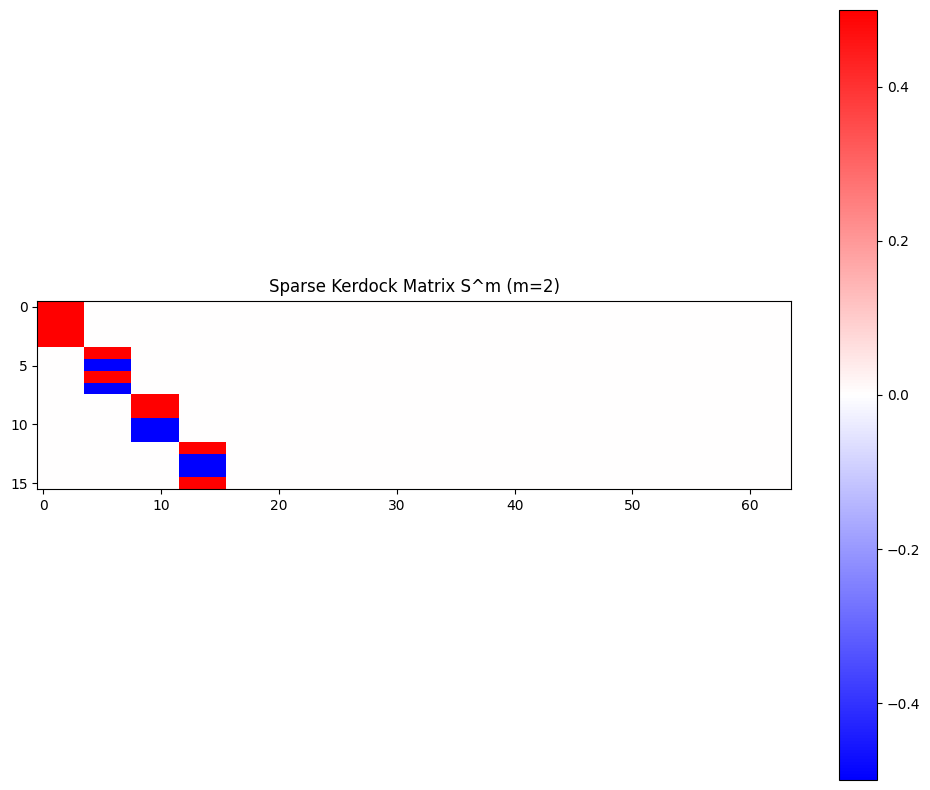

J^m shape: (4, 16)
K^m shape: (16, 64)
S^m shape: (16, 64)
Nonzeros per row in S^m: 4 (expected 16)
Nonzeros per column in S^m: 4 (expected 4)


In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_matrix(matrix, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(np.real(matrix), cmap='bwr', interpolation='nearest')
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

def construct_kerdock_set(m):
    # Simple Kerdock set construction for m=2
    P0 = np.array([[0, 0], [0, 0]])
    P1 = np.array([[0, 1], [1, 0]])
    P2 = np.array([[1, 1], [1, 1]])
    P3 = np.array([[1, 0], [0, 1]])
    return [P0, P1, P2, P3]

def int_to_binary_array(n, width):
    return np.array([int(b) for b in np.binary_repr(n, width=width)])

def construct_Jm(m):
    N = 2**m
    J = np.zeros((N, N**2), dtype=complex)
    kerdock_set = construct_kerdock_set(m)
    
    for u in range(N):
        u_bin = int_to_binary_array(u, m)
        for a in range(N):
            a_bin = int_to_binary_array(a, m)
            for b in range(N):
                exponent = 2 * np.dot(u_bin, a_bin)
                exponent += np.dot(u_bin, np.dot(kerdock_set[b], u_bin))
                J[u, a*N + b] = (1/np.sqrt(N)) * 1j**(exponent % 4)
    
    return J

def construct_Km(m):
    N = 2**(2*m)
    K = np.zeros((N, N * 2**m))
    kerdock_set = construct_kerdock_set(m)
    
    for u in range(N):
        u1, u2 = u // 2**m, u % 2**m
        u1_bin = int_to_binary_array(u1, m)
        u2_bin = int_to_binary_array(u2, m)
        for a in range(2**m):
            a_bin = int_to_binary_array(a, m)
            for b in range(2**m):
                exponent = np.dot(u1_bin, a_bin) + np.dot(u2_bin, a_bin)
                exponent += 2 * np.dot(u1_bin, np.dot(kerdock_set[b], u2_bin))
                K[u, a*2**m + b] = (1/2**m) * (-1)**exponent
    
    return K

def construct_Sm(m):
    N = 2**(2*m)
    H = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
    for _ in range(m-1):
        H = np.kron(H, np.array([[1, 1], [1, -1]])) / np.sqrt(2)
    
    K = construct_Km(m)
    S = np.kron(H, np.eye(2**m)) @ K
    
    return S

# Set m = 2 for this example
m = 2

# Construct and plot J^m
J = construct_Jm(m)
plot_matrix(J, f"Delsarte-Goethals (DG) Frame J^m (m={m})")

# Construct and plot K^m
K = construct_Km(m)
plot_matrix(K, f"Incomplete DG Frame K^m (m={m})")

# Construct and plot S^m
S = construct_Sm(m)
plot_matrix(S, f"Sparse Kerdock Matrix S^m (m={m})")

print(f"J^m shape: {J.shape}")
print(f"K^m shape: {K.shape}")
print(f"S^m shape: {S.shape}")

# Check sparsity of S^m
nonzeros_per_row = np.count_nonzero(S, axis=1)
nonzeros_per_col = np.count_nonzero(S, axis=0)
print(f"Nonzeros per row in S^m: {nonzeros_per_row[0]} (expected {2**(2*m)})")
print(f"Nonzeros per column in S^m: {nonzeros_per_col[0]} (expected {2**m})")

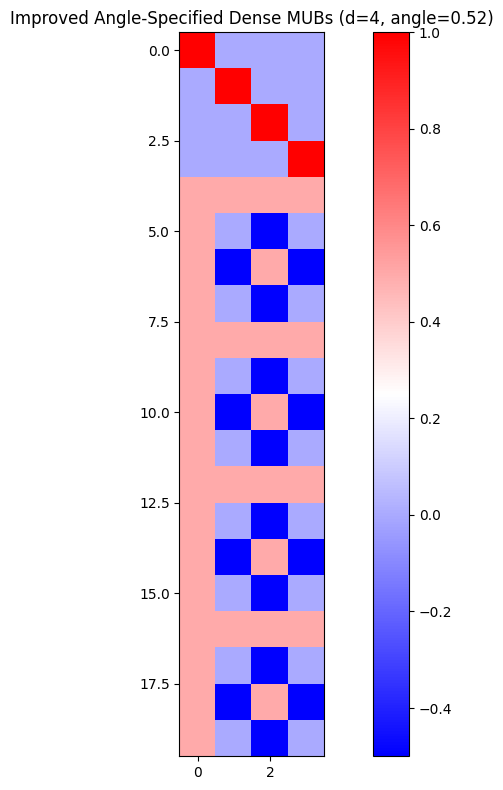

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 20 is different from 16)

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def plot_matrix(matrix, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(np.real(matrix), cmap='bwr', interpolation='nearest')
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

def construct_improved_angle_specified_mub(d, angle):
    """Construct MUBs with specified angle between rows for dimension d"""
    # Number of bases
    n_bases = d + 1
    
    # Calculate the inner product magnitude based on the specified angle
    inner_product_mag = np.cos(angle)
    
    # Create the first (standard) basis
    M = np.eye(d, dtype=complex)
    
    # Create the remaining bases
    for k in range(1, n_bases):
        basis = np.zeros((d, d), dtype=complex)
        for i in range(d):
            for j in range(d):
                phase = 2 * np.pi * i * j / d
                basis[i, j] = np.exp(1j * phase) / np.sqrt(d)
        
        # Adjust the basis to achieve the desired angle
        for i in range(d):
            for j in range(i):
                current_inner_product = np.vdot(basis[i], basis[j])
                if np.abs(current_inner_product) > 1e-10:  # Non-orthogonal vectors
                    adjustment = (inner_product_mag - np.abs(current_inner_product)) / 2
                    basis[i] += adjustment * basis[j]
                    basis[j] += adjustment * basis[i]
            basis[i] /= np.linalg.norm(basis[i])
        
        M = np.vstack((M, basis))
    
    return M

def construct_sparse_improved_mub(d, angle):
    """Construct sparse MUBs with specified angle between rows"""
    M = construct_improved_angle_specified_mub(d, angle)
    
    # Construct Hadamard matrix
    H = np.array([[np.exp(2j * np.pi * i * j / d) / np.sqrt(d) for j in range(d)] for i in range(d)])
    
    # Apply transformation
    S = np.kron(H, np.eye(d)) @ M
    
    return S

# Set parameters
d = 4  # dimension
angle = np.pi/6  # Specify the desired angle between rows (30 degrees in this case)

# Construct and plot improved angle-specified dense MUBs
M = construct_improved_angle_specified_mub(d, angle)
plot_matrix(M, f"Improved Angle-Specified Dense MUBs (d={d}, angle={angle:.2f})")

# Construct and plot improved angle-specified sparse MUBs
S = construct_sparse_improved_mub(d, angle)
plot_matrix(S, f"Improved Angle-Specified Sparse MUBs (d={d}, angle={angle:.2f})")

print(f"Dense MUBs shape: {M.shape}")
print(f"Sparse MUBs shape: {S.shape}")

# Check sparsity of S
nonzeros_per_row = np.count_nonzero(S, axis=1)
nonzeros_per_col = np.count_nonzero(S, axis=0)
print(f"Nonzeros per row in Sparse MUBs: {np.mean(nonzeros_per_row):.2f}")
print(f"Nonzeros per column in Sparse MUBs: {np.mean(nonzeros_per_col):.2f}")

# Check angles between rows
def check_angles(matrix, desired_angle):
    angles = []
    for i in range(matrix.shape[0]):
        for j in range(i+1, matrix.shape[0]):
            inner_product = np.abs(np.vdot(matrix[i], matrix[j]))
            angle = np.arccos(inner_product)
            angles.append(angle)
    
    mean_angle = np.mean(angles)
    print(f"Mean angle between rows: {mean_angle:.4f} (desired: {desired_angle:.4f})")
    print(f"Standard deviation of angles: {np.std(angles):.4f}")

check_angles(M, angle)
check_angles(S, angle)

In [42]:
M

array([[ 1.00000000e+00+0.0000000e+00j,  0.00000000e+00+0.0000000e+00j,
         0.00000000e+00+0.0000000e+00j,  0.00000000e+00+0.0000000e+00j],
       [ 0.00000000e+00+0.0000000e+00j,  1.00000000e+00+0.0000000e+00j,
         0.00000000e+00+0.0000000e+00j,  0.00000000e+00+0.0000000e+00j],
       [ 0.00000000e+00+0.0000000e+00j,  0.00000000e+00+0.0000000e+00j,
         1.00000000e+00+0.0000000e+00j,  0.00000000e+00+0.0000000e+00j],
       [ 0.00000000e+00+0.0000000e+00j,  0.00000000e+00+0.0000000e+00j,
         0.00000000e+00+0.0000000e+00j,  1.00000000e+00+0.0000000e+00j],
       [ 5.00000000e-01+0.0000000e+00j,  5.00000000e-01+0.0000000e+00j,
         5.00000000e-01+0.0000000e+00j,  5.00000000e-01+0.0000000e+00j],
       [ 5.00000000e-01+0.0000000e+00j,  3.06161700e-17+5.0000000e-01j,
        -5.00000000e-01+6.1232340e-17j, -9.18485099e-17-5.0000000e-01j],
       [ 5.00000000e-01+0.0000000e+00j, -5.00000000e-01+6.1232340e-17j,
         5.00000000e-01-1.2246468e-16j, -5.00000000e-01+1.


Angle statistics for S:
Minimum angle: 60.00 degrees
Maximum angle: 90.00 degrees
Mean angle: 78.84 degrees
Standard deviation: 14.50 degrees


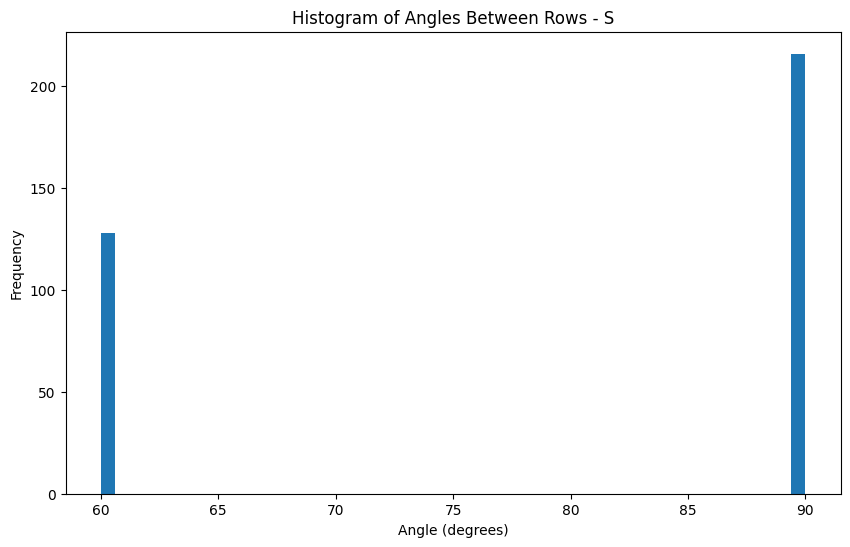

In [44]:
def check_angles(matrix, name):
    # Normalize rows
    normalized_matrix = matrix / np.linalg.norm(matrix, axis=1)[:, np.newaxis]
    
    # Compute pairwise dot products
    dot_products = np.abs(np.dot(normalized_matrix, normalized_matrix.T))
#     print(dot_products)
#     raise
    
    # Set diagonal to 0 to ignore self-dot products
    np.fill_diagonal(dot_products, 0)
    
    # Compute angles
    angles = np.arccos(dot_products)
    
    # Convert to degrees
    angles_degrees = np.degrees(angles)
    
    # Calculate statistics
    min_angle = np.min(angles_degrees[angles_degrees > 0])
    max_angle = np.max(angles_degrees)
    mean_angle = np.mean(angles_degrees[angles_degrees > 0])
    std_angle = np.std(angles_degrees[angles_degrees > 0])
    
    print(f"\nAngle statistics for {name}:")
    print(f"Minimum angle: {min_angle:.2f} degrees")
    print(f"Maximum angle: {max_angle:.2f} degrees")
    print(f"Mean angle: {mean_angle:.2f} degrees")
    print(f"Standard deviation: {std_angle:.2f} degrees")
    
    # Plot histogram of angles
    plt.figure(figsize=(10, 6))
    plt.hist(angles_degrees[angles_degrees > 0], bins=50)
    plt.title(f"Histogram of Angles Between Rows - {name}")
    plt.xlabel("Angle (degrees)")
    plt.ylabel("Frequency")
    plt.show()

# Check angles for J^m
# check_angles(J, "J^m")

# Check angles for K^m
# check_angles(K, "K^m")

# Check angles for S^m
check_angles(M,"S")

In [65]:
import math

def verify_equations(epsilon, theta, phi, k):
    # Calculate a, b, c, d
    a = math.sqrt((1 - epsilon**2) / k) * math.cos(theta)
    b = math.sqrt((1 - epsilon**2) / k) * math.sin(theta)
    c = math.sqrt((1 - epsilon**2) / k) * math.cos(phi)
    d = math.sqrt((1 - epsilon**2) / k) * math.sin(phi)
    
    # Verify equation 1: ac - bd = epsilon^2
    eq1 = a*c - b*d
    eq1_check = abs(eq1 - epsilon**2) < 1e-10  # Using a small tolerance for floating-point comparison
    
    # Verify equation 2: k(a^2 + b^2) + epsilon^2 = 1
    eq2 = k*(a**2 + b**2) + epsilon**2
    eq2_check = abs(eq2 - 1) < 1e-10
    
    # Verify equation 3: k(c^2 + d^2) + epsilon^2 = 1
    eq3 = k*(c**2 + d**2) + epsilon**2
    eq3_check = abs(eq3 - 1) < 1e-10
    
    print(f"a = {a:.6f}, b = {b:.6f}, c = {c:.6f}, d = {d:.6f}")
    print(f"Equation 1: ac - bd = {eq1:.6f} (should be {epsilon**2:.6f})")
    print(f"Equation 2: k(a^2 + b^2) + epsilon^2 = {eq2:.6f} (should be 1)")
    print(f"Equation 3: k(c^2 + d^2) + epsilon^2 = {eq3:.6f} (should be 1)")
    print(f"All equations satisfied: {eq1_check and eq2_check and eq3_check}")
    return a,b,c,d

# Example usage
k = 2  # You can change this value
epsilon = 0.1  # You can change this value, ensuring epsilon <= 1/sqrt(k+1)
temp = math.acos(k * epsilon**2 / (1 - epsilon**2))
theta = phi = 0.5 * temp  # Default values

print("Default values:")
verify_equations(epsilon, theta, phi, k)

# You can manually adjust epsilon, theta, and phi here
print("\nManually adjusted values (corrected):")
epsilon = 0.1
temp = math.acos(k * epsilon**2 / (1 - epsilon**2))
theta = 0.1 * temp
phi = temp - theta  # Ensure theta + phi = temp
a,b,c,d = verify_equations(epsilon, theta, phi, k)

Default values:
a = 0.502494, b = 0.492443, c = 0.502494, d = 0.492443
Equation 1: ac - bd = 0.010000 (should be 0.010000)
Equation 2: k(a^2 + b^2) + epsilon^2 = 1.000000 (should be 1)
Equation 3: k(c^2 + d^2) + epsilon^2 = 1.000000 (should be 1)
All equations satisfied: True

Manually adjusted values (corrected):
a = 0.695121, b = 0.108657, c = 0.122678, d = 0.692784
Equation 1: ac - bd = 0.010000 (should be 0.010000)
Equation 2: k(a^2 + b^2) + epsilon^2 = 1.000000 (should be 1)
Equation 3: k(c^2 + d^2) + epsilon^2 = 1.000000 (should be 1)
All equations satisfied: True


In [52]:
np.isclose(theta + phi, temp)

True

In [107]:
n = 5
k = 4
S = np.arange(1,n+1)
M = np.diag(S).astype(float)

C = S[k-1] / (n*2-1)
M[:,k-1] = C
M[k-1,:] = C
M[k-1,k-1] = C

U, S, Vt = np.linalg.svd(M)

In [108]:
M

array([[1.        , 0.        , 0.        , 0.44444444, 0.        ],
       [0.        , 2.        , 0.        , 0.44444444, 0.        ],
       [0.        , 0.        , 3.        , 0.44444444, 0.        ],
       [0.44444444, 0.44444444, 0.44444444, 0.44444444, 0.44444444],
       [0.        , 0.        , 0.        , 0.44444444, 5.        ]])

In [109]:
S

array([5.04499306, 3.08026742, 2.11101314, 1.1748571 , 0.03331374])

In [110]:
U

array([[-0.01106206,  0.03781086,  0.09573101,  0.9087303 , -0.40434241],
       [-0.01469493,  0.07281225,  0.95807042, -0.19257021, -0.19874662],
       [-0.02188074,  0.9799331 , -0.11964002, -0.08706055, -0.13175382],
       [-0.10067843,  0.17697757,  0.23930641,  0.35752037,  0.87946258],
       [-0.99450831, -0.04097274, -0.03681512, -0.04154039, -0.0786988 ]])

In [6]:
v = np.ones(n) / np.sqrt(n)
v = np.zeros(n)
v[0] = 1
compute_measures(v)

(0.0, -1.000000082690371e-10)

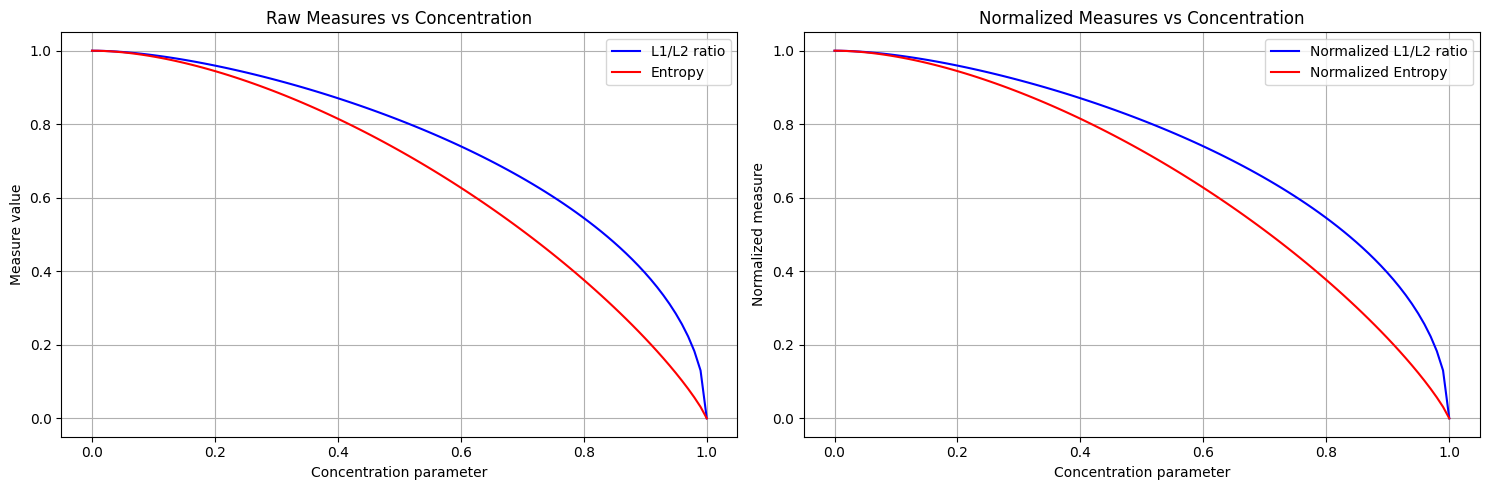


Example values at different concentrations:

Concentration: 0.00
Vector[0]: 0.316, Vector[1:]: 0.316
L1/L2 ratio: 1.000
Entropy: 1.000

Concentration: 0.50
Vector[0]: 0.742, Vector[1:]: 0.224
L1/L2 ratio: 0.811
Entropy: 0.728

Concentration: 0.90
Vector[0]: 0.954, Vector[1:]: 0.100
L1/L2 ratio: 0.395
Entropy: 0.217

Concentration: 0.99
Vector[0]: 0.995, Vector[1:]: 0.032
L1/L2 ratio: 0.130
Entropy: 0.031


In [160]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def compute_measures(v):
    """Compute L1/L2 ratio and entropy for a vector"""
    # Normalize to unit L2 norm
    v = v / np.linalg.norm(v)
    n = len(v)
    # Compute L1/L2 ratio (remember v is already normalized in L2)
    l1_l2 = (np.sum(np.abs(v))-1) / (np.sqrt(n) - 1) 
    # Compute entropy (use only non-zero elements to avoid log(0))
    v_squared = v * v
    ent = -np.sum(v_squared * np.log(v_squared + 1e-10)) / np.log(n)
    return l1_l2, ent

def compute_entropy(matrix):
    """Compute entropy for a vector"""
    # Compute entropy (use only non-zero elements to avoid log(0))
    squared = matrix ** 2
    # Compute entropy (use only non-zero elements to avoid log(0))
    n = matrix.shape[0]  # dimension of vectors
    entropies = -np.sum(squared * np.log(squared + 1e-10), axis=0) / np.log(n)  # shape (d,)
    return entropies

# Parameters
n = 10  # dimension of vector
steps = 100  # number of concentration steps

# Initialize arrays to store results
l1_l2_ratios = []
entropies = []
concentrations = np.linspace(0, 1, steps)

for c in concentrations:
    # Create vector: one large component and rest uniform
    v = np.ones(n) / np.sqrt(n)
    # Gradually increase first component while maintaining unit L2 norm
    v[0] = np.sqrt(1 - (n-1)*(1-c)/(n))
    remaining = np.sqrt((1 - v[0]*v[0])/(n-1))
    v[1:] = remaining
    
    # Compute measures
    l1_l2, ent = compute_measures(v)
    l1_l2_ratios.append(l1_l2)
    entropies.append(ent)

# Normalize measures to [0,1] for comparison
norm_l1_l2 = (np.array(l1_l2_ratios) - min(l1_l2_ratios)) / (max(l1_l2_ratios) - min(l1_l2_ratios))
norm_entropy = (np.array(entropies) - min(entropies)) / (max(entropies) - min(entropies))

# Create plots
plt.figure(figsize=(15, 5))

# Plot 1: Raw measures
plt.subplot(1, 2, 1)
plt.plot(concentrations, l1_l2_ratios, 'b-', label='L1/L2 ratio')
plt.plot(concentrations, entropies, 'r-', label='Entropy')
plt.xlabel('Concentration parameter')
plt.ylabel('Measure value')
plt.title('Raw Measures vs Concentration')
plt.legend()
plt.grid(True)

# Plot 2: Normalized measures
plt.subplot(1, 2, 2)
plt.plot(concentrations, norm_l1_l2, 'b-', label='Normalized L1/L2 ratio')
plt.plot(concentrations, norm_entropy, 'r-', label='Normalized Entropy')
plt.xlabel('Concentration parameter')
plt.ylabel('Normalized measure')
plt.title('Normalized Measures vs Concentration')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print some example values
print("\nExample values at different concentrations:")
for c in [0, 0.5, 0.9, 0.99]:
    v = np.ones(n) / np.sqrt(n)
    v[0] = np.sqrt(1 - (n-1)*(1-c)/(n))
    remaining = np.sqrt((1 - v[0]*v[0])/(n-1))
    v[1:] = remaining
    l1_l2, ent = compute_measures(v)
    print(f"\nConcentration: {c:.2f}")
    print(f"Vector[0]: {v[0]:.3f}, Vector[1:]: {v[1]:.3f}")
    print(f"L1/L2 ratio: {l1_l2:.3f}")
    print(f"Entropy: {ent:.3f}")

In [46]:
Us = []
names = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]
for i in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]:
    US = np.load(f'output/US_exact1000_hyperboloid_10000_{i}.npz')
    U, S = US['U'], US['S']
    Us.append(U)

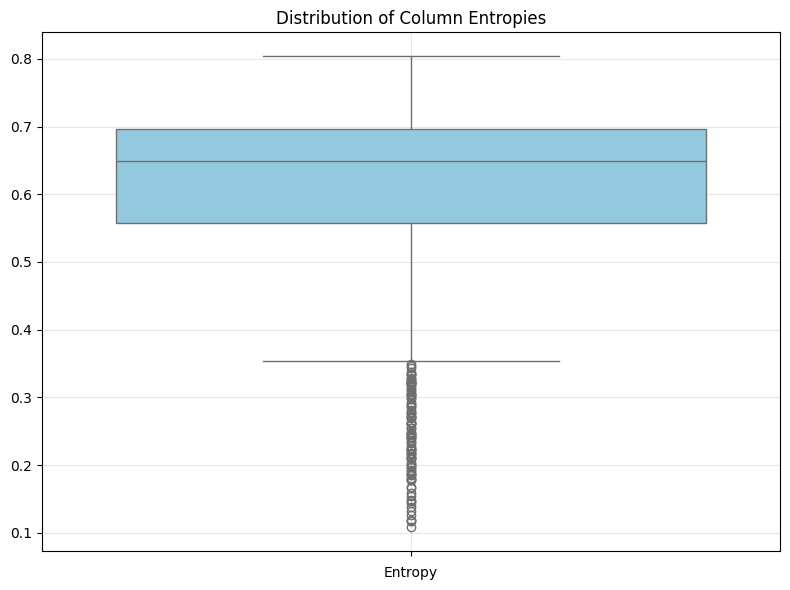

In [201]:
import seaborn as sns
def compute_entropy(matrix):
    """Compute entropy for a vector"""
    # Compute entropy (use only non-zero elements to avoid log(0))
    squared = matrix ** 2
    # Compute entropy (use only non-zero elements to avoid log(0))
    n = matrix.shape[0]  # dimension of vectors
    entropies = -np.sum(squared * np.log(squared + 1e-10), axis=0) / np.log(n)  # shape (d,)
    return entropies


name = f'output/US_exact1000_hyperboloid_10000_10.0.npz'
# name = f'output/US_exact1000_ex10.npz'
# name = f'output/US_exact1000_bundle1.npz'
# name = f'output/US_exact1000_kronecker_graph_13_0.9.npz'
US = np.load(name)
U, S = US['U'], US['S']

ent = compute_entropy(U) #* np.log(S)
ents.append(ent)

plt.figure(figsize=(8, 6))
sns.boxplot(data=ent, orient='v', color='skyblue')
plt.xlabel("Entropy")
plt.title("Distribution of Column Entropies")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

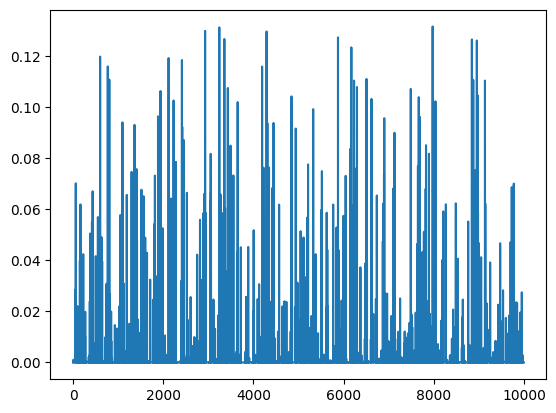

In [202]:
plt.plot(U[:,0])

In [203]:
import numpy as np

def compute_row_mutual_coherence(U, S, normalize=True):
    """
    Compute row-wise mutual coherence using first k columns of U and associated singular values
    
    Args:
        U: Left singular vectors (m x k matrix)
        S: Singular values (k-length array)
        normalize: Whether to normalize by row norms (default True)
    
    Returns:
        mutual_coherence: Maximum absolute correlation between any two rows
        row_correlations: Matrix of absolute correlations between rows
    """
    # Scale U by singular values to get row representations in k-dimensional space
    U_scaled = U * S

    # Compute gram matrix of rows (this gives correlations between rows)
    row_correlations = np.abs(U_scaled @ U_scaled.T)
    
    if normalize:
        # Compute row norms for normalization
        row_norms = np.sqrt(np.diag(row_correlations))
        row_norms[row_norms == 0] = 1
        # Normalize to get cosine similarities
        row_correlations = row_correlations / row_norms[:, None]
        row_correlations = row_correlations / row_norms[None, :]
    
    # Zero out diagonal to exclude self-correlations
    np.fill_diagonal(row_correlations, 0)
    
    # Find indices of maximum correlation
    i, j = np.unravel_index(np.argmax(row_correlations), row_correlations.shape)
    
    # Get maximum off-diagonal element
    mutual_coherence = row_correlations[i, j]
    
    return mutual_coherence, (i, j)
#     mutual_coherence = np.max(row_correlations)
#     print(row_correlations.shape)
#     print(row_correlations)
    
#     return mutual_coherence

compute_row_mutual_coherence(U, S)

(1.0000000000000002, (2829, 5179))

0.9999999999999996


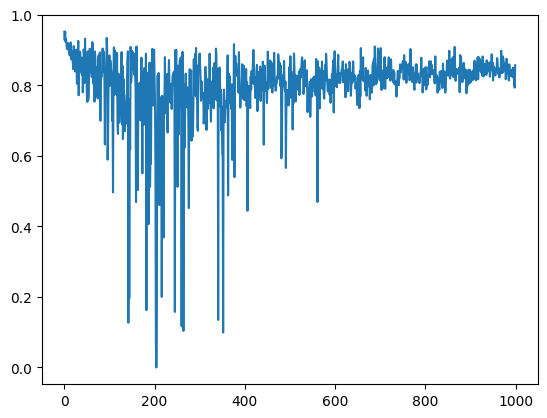

In [180]:
# plt.plot(np.arange(len(S)), ent * np.log(S))
plt.plot(np.arange(len(S)), ent)
# plt.plot(np.arange(len(S)), np.log(S))
plt.show()

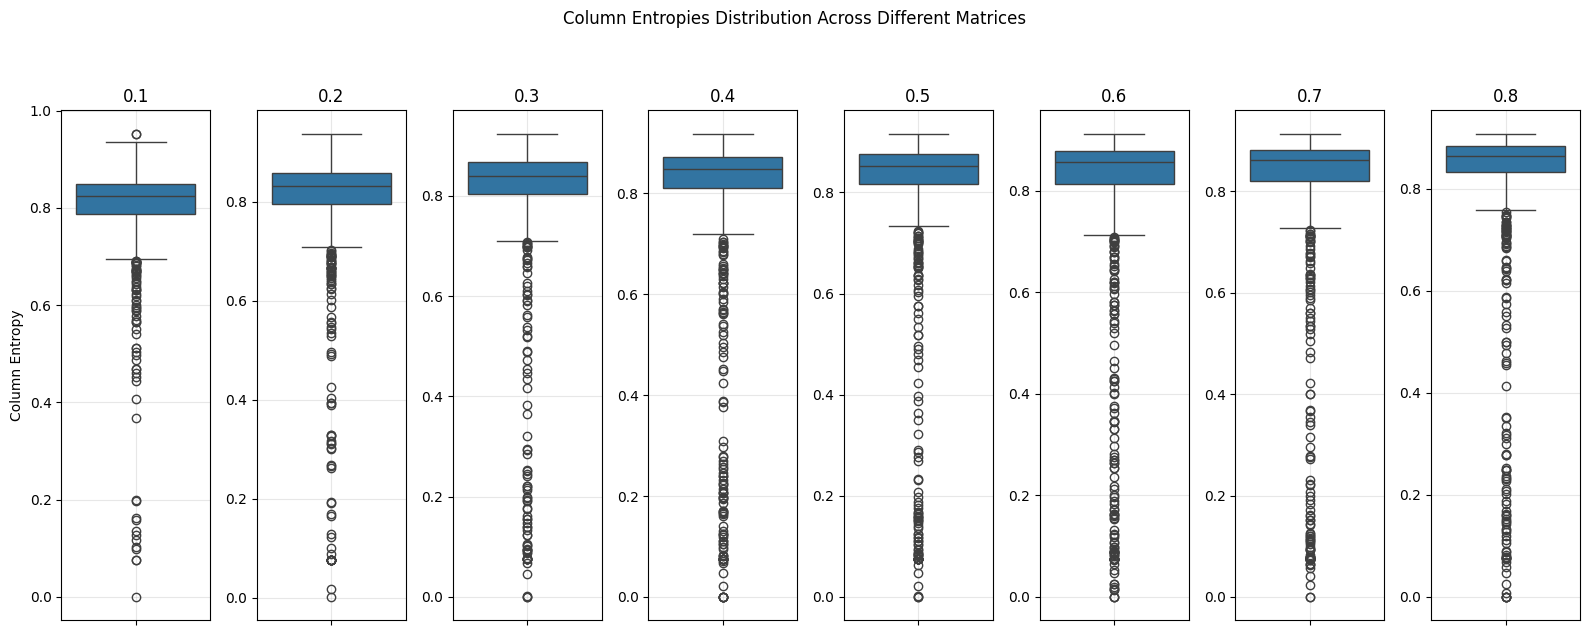

In [177]:
# Create figure with subplots
fig, axes = plt.subplots(1, len(names), figsize=(16, 6))
fig.suptitle('Column Entropies Distribution Across Different Matrices', y=1.05)


# Plot each matrix's entropy distribution separately
for i, (ent, name) in enumerate(zip(ents, names)):
    sns.boxplot(y=ent, ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel('')
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].set_ylabel('Column Entropy')
    else:
        axes[i].set_ylabel('')
        
plt.tight_layout()
plt.show()

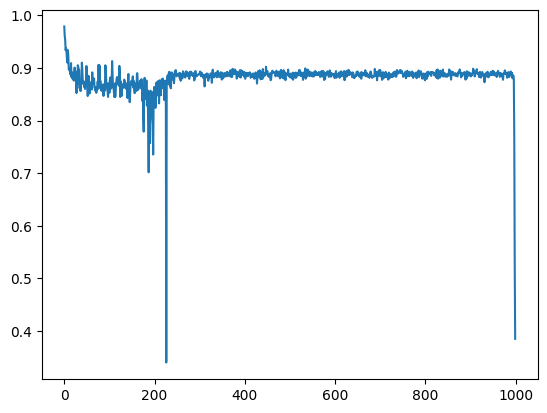

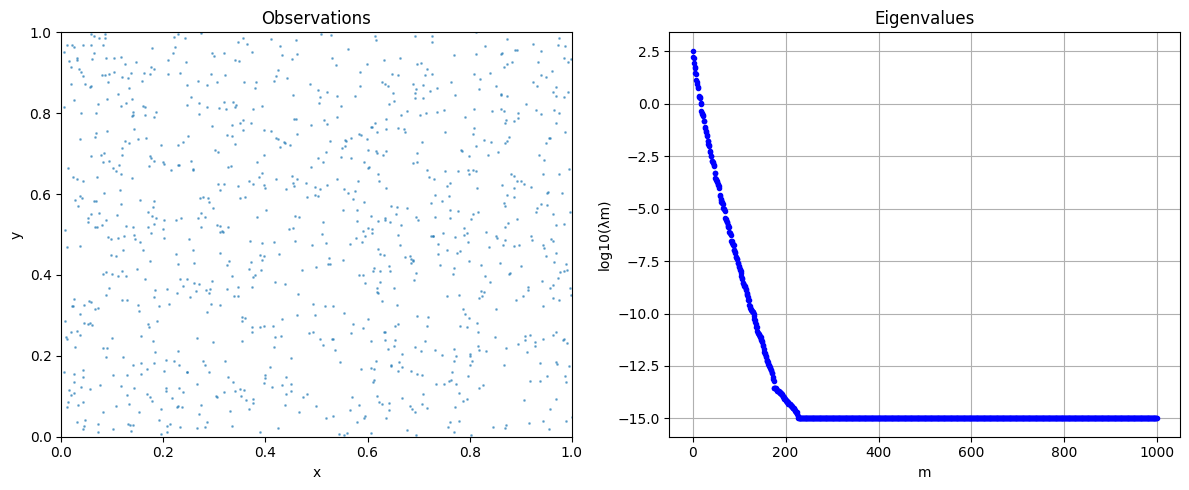

In [159]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

def generate_points(n, d=2):
    """Generate n random points in d dimensions in [0,1]^d"""
    return np.random.rand(n, d)

def compute_gaussian_kernel(X, sigma=0.3):
    """Compute Gaussian kernel matrix for data points X"""
    # Compute pairwise squared Euclidean distances
    sq_dists = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=2)
    return np.exp(-sq_dists / (2 * sigma**2))


def plot_kernel_analysis(n_points=1000, dim=2, sigma=0.3):
    """Generate points, compute kernel matrix, and plot results"""
    # Set random seed for reproducibility
    np.random.seed(42)
    
    # Generate random points
    X = generate_points(n_points, dim)
    
    # Compute kernel matrix
    K = compute_gaussian_kernel(X, sigma)
    
    # Compute eigenvalues
    eigenvals, evecs = eigh(K)
    # Sort in descending order
    eigenvals = eigenvals[::-1]
    evecs = evecs[:, ::-1]
    ent = compute_entropy(evecs) 
    plt.plot(np.arange(len(S)), ent)
    plt.show()
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot random points
    ax1.scatter(X[:, 0], X[:, 1], alpha=0.5, s=1)
    ax1.set_title('Observations')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    
    # Plot eigenvalues on log scale
    ax2.plot(np.arange(len(eigenvals)), np.log10(np.maximum(eigenvals, 1e-15)), 'b.')
    ax2.set_title('Eigenvalues')
    ax2.set_xlabel('m')
    ax2.set_ylabel('log10(λm)')
    ax2.grid(True)
    
    plt.tight_layout()
    return fig

# Generate and display the plot
fig = plot_kernel_analysis(n_points=1000, dim=2, sigma=0.3)
plt.show()

In [169]:
def compute_coherence_and_leverage(U, rank=None):
    n = U.shape[1]  # number of columns in original matrix
    
    # Compute coherence
    coherence = np.max(U**2)
    
    return coherence

compute_coherence_and_leverage(U)

0.40936106479579326

In [449]:
def gram_schmidt(A):
    """
    Orthonormalizes a set of vectors using the Gram-Schmidt process.

    Parameters:
    A (numpy.ndarray): Matrix whose columns are the vectors to orthonormalize.

    Returns:
    numpy.ndarray: Matrix whose columns are the orthonormalized vectors.
    """

    Q = np.zeros_like(A)
    for i in range(A.shape[1]):
        v = A[:, i]
        for j in range(i):
            v -= np.dot(Q[:, j], A[:, i]) * Q[:, j]
        Q[:, i] = v / np.linalg.norm(v)
    return Q

n = 7
rho = 0.2
A = np.random.randn(n, n)
A[:n//2,0] = np.random.rand(n//2) * rho
A[n//2:,0] = np.random.rand(n-n//2) * (1-rho)
Q, _ = np.linalg.qr(A)
S = np.diag(np.arange(1,n+1)[::-1])
A = Q @ S @ Q.T

In [450]:
A1 = A[:n//2, :]
U, S, Vt = np.linalg.svd(A)
U_hat, S_hat, Vt_hat = np.linalg.svd(A1)

In [452]:
S_hat, S

(array([5.55211039, 2.70195724, 1.87420669]),
 array([7., 6., 5., 4., 3., 2., 1.]))

In [453]:
U_hat.shape

(3, 3)

In [454]:
Vt_hat.T[:,j]

array([ 0.60469381, -0.57178587,  0.07925762, -0.43349976, -0.01267154,
        0.30801645, -0.13478803])

In [455]:
i = 1
j = 0

Vt.T[:,i].reshape(1,-1) @ Vt_hat.T[:,j].reshape(-1,1)

array([[-0.77032101]])

In [456]:
Vt.T[:n//2, i].reshape(1,-1) @ U_hat[:,j].reshape(-1,1) * S[i] / S_hat[j]

array([[-0.77032101]])

In [457]:
S[i] / S_hat[j]

1.0806701552348177

In [458]:
Vt_hat.T[:,j].reshape(-1,1) .shape

(7, 1)

In [459]:
Vt.T[:, i].reshape(1,-1) @ Vt_hat.T[:,j].reshape(-1,1) 

array([[-0.77032101]])

In [460]:
v_sum = np.zeros(n//2)

for j in range(len(u_sum)):
    inner_prod = S_hat[j] * Vt.T[:, i].reshape(1,-1) @ Vt_hat.T[:,j].reshape(-1,1) 
    print(inner_prod)
    v_sum[j] = inner_prod
    print(v_sum)
U_hat @ v_sum, np.linalg.norm(v_sum)

[[-4.27690728]]
[-4.27690728  0.          0.        ]
[[1.00258883]]
[-4.27690728  1.00258883  0.        ]
[[0.4743395]]
[-4.27690728  1.00258883  0.4743395 ]


/tmp/ipykernel_2779267/1274239083.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  v_sum[j] = inner_prod


(array([ 2.92413547,  2.69451721, -1.92642856]), 4.418384119290514)

In [461]:
v_sum = np.zeros(n//2)

for j in range(len(u_sum)):
    inner_prod = S[i] * Vt.T[:n//2, i].reshape(1,-1) @ U_hat[:,j].reshape(-1,1)
    print(inner_prod)
    v_sum[j] = inner_prod
    print(v_sum)
U_hat @ v_sum, np.linalg.norm(v_sum)

[[-4.27690728]]
[-4.27690728  0.          0.        ]
[[1.00258883]]
[-4.27690728  1.00258883  0.        ]
[[0.4743395]]
[-4.27690728  1.00258883  0.4743395 ]


/tmp/ipykernel_2779267/181730281.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  v_sum[j] = inner_prod


(array([ 2.92413547,  2.69451721, -1.92642856]), 4.418384119290513)

In [462]:
U_hat, S_hat

(array([[-0.6247862 , -0.11410771,  0.77241286],
        [-0.74716392, -0.19983957, -0.63388502],
        [ 0.22668982, -0.97316164,  0.03959984]]),
 array([5.55211039, 2.70195724, 1.87420669]))

In [463]:
u_sum = np.zeros(n//2)

for j in range(len(u_sum)):
    inner_prod = Vt.T[:n//2, i].reshape(1,-1) @ U_hat[:,j].reshape(-1,1) 
    print(inner_prod)
    u_sum += inner_prod.reshape(-1) * U_hat[:,j].reshape(-1)
    print(u_sum)
S[i] * u_sum, np.linalg.norm(u_sum)

[[-0.71281788]]
[ 0.44535878  0.5325918  -0.16158856]
[[0.16709814]]
[ 0.42629159  0.49919898 -0.32420205]
[[0.07905658]]
[ 0.48735591  0.4490862  -0.32107143]


(array([ 2.92413547,  2.69451721, -1.92642856]), 0.7363973532150861)

In [464]:
S[i] * Vt.T[:n//2, i], np.linalg.norm(S[i] * Vt.T[:n//2, i])

(array([ 2.92413547,  2.69451721, -1.92642856]), 4.418384119290511)

In [465]:
Vt.T[:n//2, i].reshape(1,-1) @ U_hat[:,j].reshape(-1,1)

array([[0.07905658]])

In [466]:
S_hat

array([5.55211039, 2.70195724, 1.87420669])

In [467]:
V 

array([[-0.28771008,  0.07223197, -0.66450312, -0.62167293, -0.28976512],
       [ 0.13561837, -0.81005495, -0.47134319,  0.25707068,  0.19279237],
       [ 0.26842388,  0.23743123, -0.30930446,  0.55340201, -0.68531161],
       [ 0.32569193,  0.51757117, -0.47313398,  0.12537431,  0.62166741],
       [-0.84894284,  0.11974983, -0.12940703,  0.47483148,  0.15081414]])

In [497]:
U_US, S_US, Vt_US = np.linalg.svd(U[:n//2,:] @ np.diag(S), full_matrices=False)
S_US

array([5.55211039, 2.70195724, 1.87420669])

In [501]:
S[j] * U[:n//2,j:j+1] @ U[:n//2,j:j+1].T @ U_US[:,i:i+1] 

array([[-0.26867179],
       [-0.21974554],
       [-0.0130648 ]])

In [516]:
V1 = U[:n//2,:] @ np.diag(S)
(V1 @ V1.T) @ U_US[:,0] * (1/S_US[0])

array([-3.46888196, -4.14833658,  1.2586069 ])

In [522]:
i = 0
sum_ = np.zeros(U_US.shape[0])
for j in range(Vt_US.shape[1]):
    temp = S[j]**2 * (U[:n//2,j:j+1] @ U[:n//2,j:j+1].T @ U_US[:,i:i+1])
    sum_ += temp.reshape(-1)
    print(sum_)
    
sum_

[-1.88070251 -1.5382188  -0.09145363]
[-14.3869588  -13.06241906   8.14770271]
[-19.66002381 -22.42266741   6.34420351]
[-19.64422867 -22.43011897   6.37095934]
[-19.17886037 -23.08421562   6.98494177]
[-19.17882641 -23.08382239   6.98633437]
[-19.25961559 -23.03202266   6.98792445]


array([-19.25961559, -23.03202266,   6.98792445])

In [519]:
S_US[0]**2 * U_US[:,i:i+1] 

array([[-19.25961559],
       [-23.03202266],
       [  6.98792445]])

In [544]:
i = 1
sum_ = 0
for j in range(Vt_US.shape[1]):
    temp = S[j]**2 * (U[:n//2,j:j+1].T @ U_US[:,i:i+1])**2
    sum_ += temp
    print(sum_)
    
sum_, S_US[i]**2

[[0.16205869]]
[[1.16724305]]
[[2.97610994]]
[[3.36969466]]
[[4.17138924]]
[[7.2999808]]
[[7.3005729]]


(array([[7.3005729]]), 7.300572904528315)

In [545]:
U_US[:,i:i+1].T @ U[:n//2,:]

array([[ 0.05750931,  0.16709814, -0.26898824,  0.15684083, -0.298458  ,
        -0.88439125, -0.02433325]])

In [546]:
(U_US @ np.diag(S_US) @ Vt_US).shape

(3, 7)

In [547]:
# ei = np.zeros(U_US.shape[0])
# ei[i] = 1
inner_prods = S_US[i] * Vt_US[i,:] @ np.diag(1/S)
np.linalg.norm(inner_prods)**2

0.9999999999999998

In [562]:
j = 0
(U[:n//2,j:j+1].T@U_US[:,i:i+1])**2,  S_US[i]

(array([[0.00330732]]), 2.701957235880745)

In [560]:
numerator = S_US[i]**2 - np.sum([S[k]**2*(U[:n//2,k:k+1].T@U_US[:,i:i+1]).reshape(-1)**2 for k in range(U.shape[1]) if k != j])
numerator = S_US[i]**2 - np.sum([S[k]**2*(U[:n//2,k:k+1].T@U_US[:,i:i+1]).reshape(-1)**2 for k in range(U.shape[1]) if k != j])
numerator / S[j]**2

0.0033073202274682646

In [580]:
(1-(U[:n//2,j:j+1].T@U_US[:,i:i+1]).reshape(-1)**2), np.sum([(U[:n//2,k:k+1].T@U_US[:,i:i+1]).reshape(-1)**2 for k in range(U.shape[1]) if k != j])

(array([0.99669268]), 0.9966926797725326)

In [583]:
# numerator = S_US[i]**2 - S[-1]**2 * np.sum([(U[:n//2,k:k+1].T@U_US[:,i:i+1]).reshape(-1)**2 for k in range(U.shape[1]) if k != j])
numerator = S_US[i]**2 - S[-1]**2 * (1-S[j]**2*(U[:n//2,j:j+1].T@U_US[:,i:i+1]).reshape(-1)**2)
numerator / S[j]**2

array([0.13189044])

In [571]:
S_US[i], S[i], S[n-n//2+i]

(2.701957235880745, 5.999999999999995, 2.0000000000000004)

In [566]:
np.linalg.norm(U[:n//2,j:j+1])

0.22884817410813618

In [548]:
U_U, S_U, Vt_U = np.linalg.svd(U[:n//2,:], full_matrices=False)
S_U

array([1., 1., 1.])

In [549]:
U[:n//2,:] @ np.diag(S)

array([[-1.23912726,  2.92413547,  1.67764122, -0.37605005,  0.8014718 ,
         0.04178507, -0.73343147],
       [-1.01347706,  2.69451721,  2.97799068,  0.17740653, -1.12650565,
         0.48379186,  0.47025538],
       [-0.06025551, -1.92642856,  0.5737886 , -0.63700204,  1.05741969,
         1.71331635,  0.01443522]])

In [550]:
Vt_U @ np.diag(S), Vt_U

(array([[ 1.23912726, -2.92413547, -1.67764122,  0.37605005, -0.8014718 ,
         -0.04178507,  0.73343147],
        [-0.47282221, -0.64386677,  1.75076739, -0.50716178,  0.49878812,
          1.76036037,  0.20707036],
        [ 0.89844624, -3.24915151, -2.47638354, -0.42430131,  1.46231384,
          0.2657797 , -0.42245752]]),
 array([[ 0.17701818, -0.48735591, -0.33552824,  0.09401251, -0.26715727,
         -0.02089254,  0.73343147],
        [-0.06754603, -0.10731113,  0.35015348, -0.12679044,  0.16626271,
          0.88018019,  0.20707036],
        [ 0.12834946, -0.54152525, -0.49527671, -0.10607533,  0.48743795,
          0.13288985, -0.42245752]]))

In [551]:
U[:n//2,:].T @ 

SyntaxError: invalid syntax (1101803287.py, line 1)

In [475]:
U_U @ np.diag(S_U) @ Vt_U @ np.diag(S)

array([[-1.23912726,  2.92413547,  1.67764122, -0.37605005,  0.8014718 ,
         0.04178507, -0.73343147],
       [-1.01347706,  2.69451721,  2.97799068,  0.17740653, -1.12650565,
         0.48379186,  0.47025538],
       [-0.06025551, -1.92642856,  0.5737886 , -0.63700204,  1.05741969,
         1.71331635,  0.01443522]])

In [478]:
np.linalg.svd(U[:n//2+1,:])

SVDResult(U=array([[ 1.10933565e-31, -1.00000000e+00,  1.97215226e-31,
        -7.45497582e-16],
       [ 4.33991421e-01,  6.50435073e-16, -2.24549046e-01,
        -8.72484483e-01],
       [ 3.55679553e-01, -2.94419089e-16, -8.47067080e-01,
         3.94929636e-01],
       [ 8.27733956e-01, -2.14518675e-16,  4.81720965e-01,
         2.87752341e-01]]), S=array([1., 1., 1., 1.]), Vh=array([[-0.18686548, -0.30734456,  0.55190909,  0.50490142, -0.31969269,
         0.45085278, -0.07496587],
       [ 0.17701818, -0.48735591, -0.33552824,  0.09401251, -0.26715727,
        -0.02089254,  0.73343147],
       [-0.03059903, -0.0547059 , -0.083937  ,  0.44053941, -0.37842265,
        -0.75600088, -0.28321289],
       [ 0.08086723, -0.65352102, -0.38651272,  0.08693398,  0.36875434,
         0.1415837 , -0.50338401],
       [ 0.24548016,  0.23976976,  0.03422482,  0.66419869,  0.61181781,
        -0.0447634 ,  0.25217833],
       [-0.20584935,  0.40865089, -0.64983675,  0.30517243, -0.29608491,
   

In [492]:
np.diag(S) @ np.diag(S.T)

array([[49.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0., 36.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0., 25.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0., 16.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  9.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  4.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1.]])

In [493]:
U[:n//2+1,:] @ (np.diag(S) @ np.diag(S.T)) @ U[:n//2+1,:].T

array([[14.22392308, 12.83669927, -3.44782192, -5.94648685],
       [12.83669927, 18.91166997, -3.88951103, -0.494946  ],
       [-3.44782192, -3.88951103,  8.50356037,  3.77093753],
       [-5.94648685, -0.494946  ,  3.77093753, 19.32772209]])

In [484]:
X = np.array([[1/np.sqrt(2), 1/np.sqrt(2)], [1/np.sqrt(2),1/np.sqrt(2)]])
X[:1,:]

array([[0.70710678, 0.70710678]])

In [483]:
np.linalg.svd(X[:1,:])

SVDResult(U=array([[-1.]]), S=array([1.]), Vh=array([[-0.70710678, -0.70710678],
       [-0.70710678,  0.70710678]]))

In [474]:
# TODO: construct real orthgonal V such that V[0]'s first n//2 has norm rho

In [443]:
import numpy as np

# Create a symmetric PD matrix A
n = 5
k = 3
l = 1  # We'll check sum of projections after first singular vector

# Create random symmetric PD matrix
np.random.seed(42)
V = np.random.randn(n, n)
V, _ = np.linalg.qr(V)  # Orthogonal matrix
sigma = np.array([10., 8., 5., 3., 1.])  # Eigenvalues
A = V @ np.diag(sigma) @ V.T

# Get v1 (dominant eigenvector)
v1 = V[:, 0]
bar_v1 = v1[:k]

print("1. Verify A is symmetric PD:")
print(np.allclose(A, A.T))
print("Eigenvalues:", np.linalg.eigvals(A))

# Get A1 (first k rows)
A1 = A[:k, :]
U, S1, Wt = np.linalg.svd(A1)

print("\n2. Verify A1 = S1*A relation:")
S1_mat = np.zeros((k, n))
S1_mat[:k, :k] = np.eye(k)
print(np.allclose(A1, S1_mat @ A))

# Get uj vectors (left singular vectors of A1)
u = U[:, :k]  # Only need first k

print("\n3. Verify bar_v1 decomposition:")
# Projection onto first l vectors
P_l_bar_v1 = sum(np.dot(bar_v1, U[:, j]) * U[:, j] for j in range(l+1))
remainder = bar_v1 - P_l_bar_v1

print("Original bar_v1:", bar_v1)
print("Reconstruction:", P_l_bar_v1 + remainder)
print("Orthogonality of P_l and remainder:", np.dot(P_l_bar_v1, remainder))

print("\n4. Verify key inequality:")
# Compute left side: ||bar_v1 - P_l(bar_v1)||^2
left_side = np.sum(remainder**2)

# Compute right side: (σ_{l+1}(A)/σ_1(A))^2 ||bar_v1||^2
right_side = (sigma[l+1]/sigma[0])**2 * np.sum(bar_v1**2)

print(f"Left side (sum of squares after l): {left_side}")
print(f"Right side (theoretical bound): {right_side}")
print("Inequality holds:", left_side <= right_side)

print("\n5. Verify intermediate steps:")
# Verify step 6 equation
A1_remainder_norm = np.linalg.norm(A1 @ np.append(remainder, np.zeros(n-k)))**2
bound = S1[l+1]**2 * np.sum(remainder**2)
print("Step 6 inequality holds:", A1_remainder_norm <= bound)

# Verify orthogonal decomposition preservation
print("Sum of squared projections equals norm:",
      np.abs(np.sum(bar_v1**2) - (np.sum(P_l_bar_v1**2) + np.sum(remainder**2))) < 1e-10)

print("\n6. Verify singular value interlacing:")
print("A singular values:", sigma)
print("A1 singular values:", S1)
print("Interlacing holds:", np.all(S1[:k] <= sigma[:k]))

1. Verify A is symmetric PD:
True
Eigenvalues: [ 1.  3.  5. 10.  8.]

2. Verify A1 = S1*A relation:
True

3. Verify bar_v1 decomposition:
Original bar_v1: [-0.28771008  0.13561837  0.26842388]
Reconstruction: [-0.28771008  0.13561837  0.26842388]
Orthogonality of P_l and remainder: 8.061394223458812e-17

4. Verify key inequality:
Left side (sum of squares after l): 0.017041873819645243
Right side (theoretical bound): 0.04330520344080348
Inequality holds: True

5. Verify intermediate steps:
Step 6 inequality holds: True
Sum of squared projections equals norm: True

6. Verify singular value interlacing:
A singular values: [10.  8.  5.  3.  1.]
A1 singular values: [7.10543225 5.03528051 3.71804673]
Interlacing holds: True


In [371]:
import numpy as np

# Construct V
r = 6
V = np.array([
    [0, 1, 0],
    [1/(r*np.sqrt(10)), 0, 1],
    [np.sqrt(1-1/(r**2*10)), 0, 0]
])
V,_ = np.linalg.qr(V)
print("V:")
print(V)

# Verify V is orthonormal
print("\nV^T V should be identity:")
print(np.round(V.T @ V, 10))

# Construct Sigma
Sigma = np.diag([3, 2, 1])
print("\nSingular values of A:")
print(np.round(Sigma, 10))

# Construct A = VΣV^T
A = V @ Sigma @ V.T
print("\nA:")
print(np.round(A, 10))

# Get A1 (first 2 rows)
A1 = A[:2, :]
print("\nA1:")
print(np.round(A1, 10))

# Compute SVD of A1
U, s, Wt = np.linalg.svd(A1)
print("\nSingular values of A1:")
print(np.round(s, 10))

print("\nLeft singular vectors of A1 (columns of U):")
print(np.round(U, 10))

# Our bar_v1 is first two entries of v1
bar_v1 = V[:2, 0]
print("\nbar_v1:")
print(np.round(bar_v1, 10))

# Compute inner products with u1 and u2
print("\nInner products of bar_v1 with u1 and u2:")
print("bar_v1 · u1 =", np.round(np.dot(bar_v1, U[:, 0]), 10))
print("bar_v1 · u2 =", np.round(np.dot(bar_v1, U[:, 1]), 10))

# Compute squared norms of projections
proj1 = np.dot(bar_v1, U[:, 0])*U[:, 0]
proj2 = np.dot(bar_v1, U[:, 1])*U[:, 1]
print("\nSquared norms of projections:")
print("||P_1(bar_v1)||^2 =", np.round(np.linalg.norm(proj1), 10))
print("||P_2(bar_v1)||^2 =", np.round(np.linalg.norm(proj2), 10))

V:
[[ 0.00000000e+00  1.00000000e+00  1.33713673e-16]
 [-5.27046277e-02  6.24500451e-17 -9.98610145e-01]
 [-9.98610145e-01  0.00000000e+00  5.27046277e-02]]

V^T V should be identity:
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]

Singular values of A:
[[3 0 0]
 [0 2 0]
 [0 0 1]]

A:
[[ 2.         -0.          0.        ]
 [-0.          1.00555556  0.10526275]
 [ 0.          0.10526275  2.99444444]]

A1:
[[ 2.         -0.          0.        ]
 [-0.          1.00555556  0.10526275]]

Singular values of A1:
[2.         1.01105006]

Left singular vectors of A1 (columns of U):
[[-1.  0.]
 [ 0.  1.]]

bar_v1:
[ 0.         -0.05270463]

Inner products of bar_v1 with u1 and u2:
bar_v1 · u1 = -0.0
bar_v1 · u2 = -0.0527046277

Squared norms of projections:
||P_1(bar_v1)||^2 = 0.0
||P_2(bar_v1)||^2 = 0.0527046277


In [622]:
w1 = np.random.randn(size_v)
w1 = w1 / np.linalg.norm(w1)

w2 = np.random.randn(size_v)

# Make it orthogonal to w1 and w2 using Gram-Schmidt
w2 = w2 - np.dot(w2, w1) * w1 

# Normalize to make ||v3||^2 + ||v3'||^2 = 1
w2 = w2 / np.linalg.norm(w2)

# Split into v3 and v3'
v1 = w1[:v1.shape[0]]
v1_prime = w1[v1.shape[0]:]
v2 = w2[:v1.shape[0]]
v2_prime = w2[v1.shape[0]:]

verify_vector_pairs(v1, v1_prime, v2, v2_prime)

||v1|| = 0.781840
||v2|| = 0.549348
||v1'|| = 0.623479
||v2'|| = 0.835594

||v1||^2 + ||v1'||^2 = 1.0000000000
||v2||^2 + ||v2'||^2 = 1.0000000000

[v1;v1']^T [v2;v2'] = 0.0000000000

v1^T v2 = 0.4263116007
v1'^T v2' = -0.4263116007
v1^T v2 + v1'^T v2' = 0.0000000000


{'orthogonality_satisfied': True,
 'norm_sum_v1': 1.0,
 'norm_sum_v2': 1.0000000000000002,
 'inner_product_relation': True}

(10000, 3)


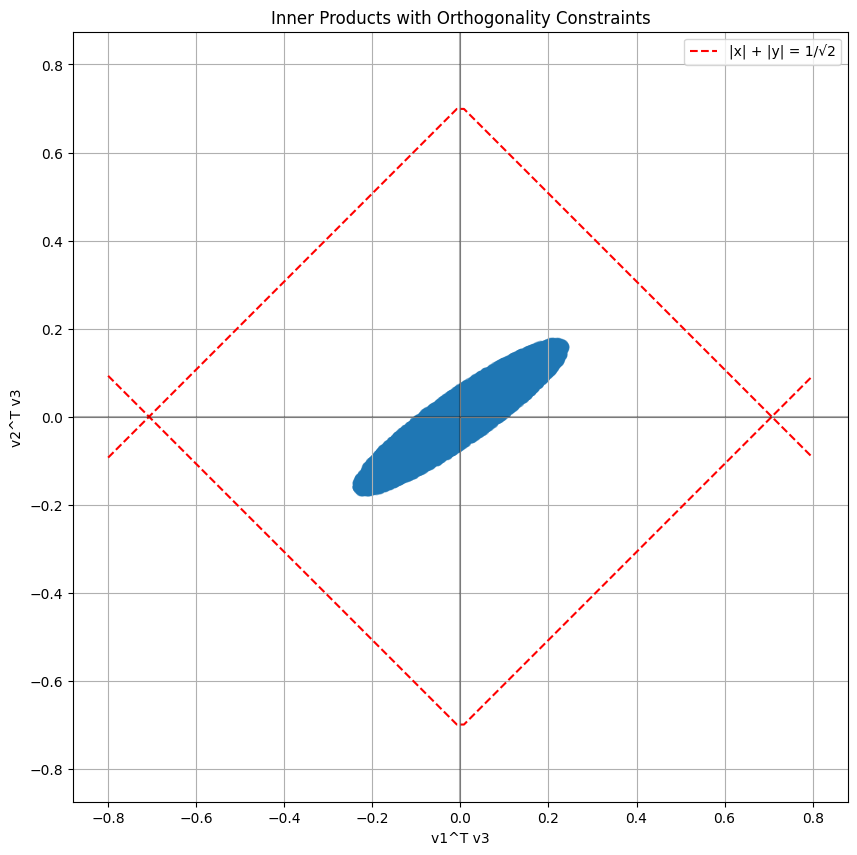

Maximum sum of absolute inner products found: 0.398


In [625]:
import numpy as np
import matplotlib.pyplot as plt

# Set up v1, v1', v2, v2'
size_v = 6
# a = b = 1/np.sqrt(2)
# angle = 1.3*np.pi/2
# v1 = np.array([a, 0, 0])
# v1_prime = np.array([0, -np.sqrt(1-a**2), 0])
# v2 = np.array([b*np.cos(angle), b*np.sin(angle), 0])
# v2_prime = np.array([-b*np.sin(angle), b*np.cos(angle), 0])

# Combine vectors
w1 = np.concatenate([v1, v1_prime])
w2 = np.concatenate([v2, v2_prime])

# Generate random vectors orthogonal to both w1 and w2
results = []
for _ in range(10000):
    # Generate random 6D vector
    w3 = np.random.randn(size_v)
    
    # Make it orthogonal to w1 and w2 using Gram-Schmidt
    w3 = w3 - np.dot(w3, w1) * w1 / np.dot(w1, w1)
    w3 = w3 - np.dot(w3, w2) * w2 / np.dot(w2, w2)
    
    # Normalize to make ||v3||^2 + ||v3'||^2 = 1
    w3 = w3 / np.linalg.norm(w3)
    
    # Split into v3 and v3'
    v3 = w3[:v1.shape[0]]
    v3_prime = w3[v1.shape[0]:]
    
    # Calculate all inner products
    ip13 = np.dot(v1, v3)  # v1^T v3
    ip23 = np.dot(v2, v3)  # v2^T v3
    ip12 = np.dot(v1, v2)  # v1^T v2
    
    if abs(np.dot(w1, w3)) < 1e-10 and abs(np.dot(w2, w3)) < 1e-10:
        results.append((ip13, ip23, ip12))

results = np.array(results)
print(results.shape)

plt.figure(figsize=(10, 10))
plt.scatter(results[:, 0], results[:, 1], alpha=0.5)
plt.xlabel('v1^T v3')
plt.ylabel('v2^T v3')
plt.title('Inner Products with Orthogonality Constraints')
plt.grid(True)

# Plot lines showing |v1^T v3| + |v2^T v3| = 1/√2
x = np.linspace(-0.8, 0.8, 100)
plt.plot(x, 1/np.sqrt(2) - abs(x), 'r--', label='|x| + |y| = 1/√2')
plt.plot(x, -1/np.sqrt(2) + abs(x), 'r--')
plt.legend()

# Add origin lines
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.axis('equal')
plt.show()

print(f"Maximum sum of absolute inner products found: {max(abs(r[0]) + abs(r[1]) for r in results):.3f}")

v1^T v2 = 0.4263116007
Maximum sum of absolute inner products found: 0.398


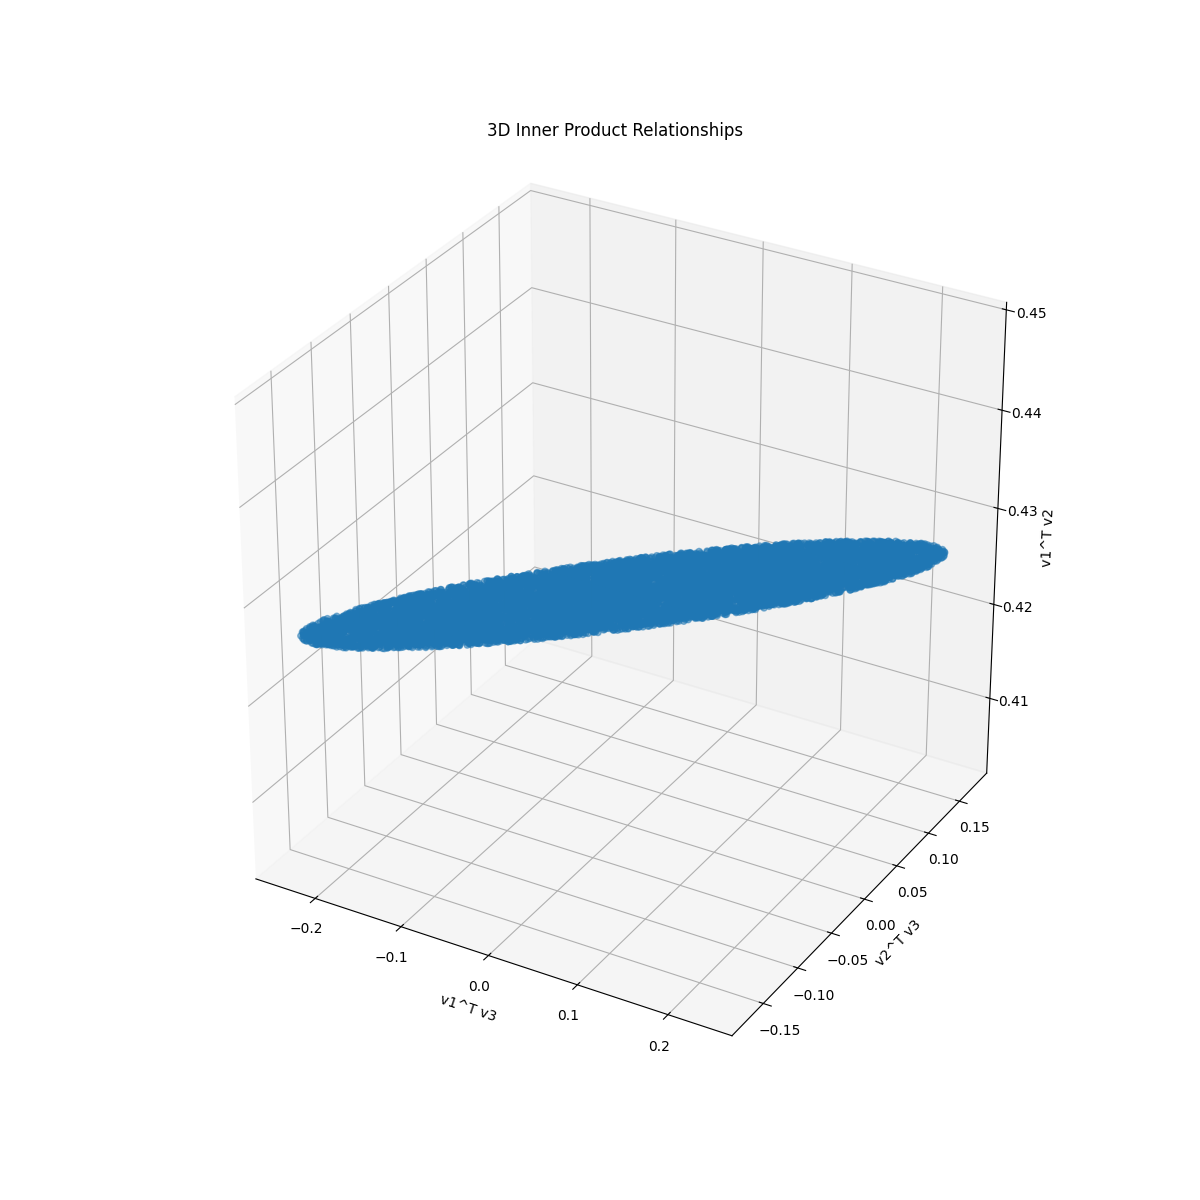

In [629]:
import ipywidgets as widgets
%matplotlib widget

# Calculate v1^T v2
v1v2 = np.dot(v1, v2)

# Create 3D plot
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot the points
ax.scatter(results[:, 0], results[:, 1], results[:, 2], alpha=0.5)

# Add labels
ax.set_xlabel('v1^T v3')
ax.set_ylabel('v2^T v3')
ax.set_zlabel('v1^T v2')

# Add title
plt.title('3D Inner Product Relationships')

# Add grid
ax.grid(True)

# Set equal aspect ratio
ax.set_box_aspect([1,1,1])

# Print the constant v1^T v2 value
print(f"v1^T v2 = {v1v2:.10f}")
print(f"Maximum sum of absolute inner products found: {max(abs(r[0]) + abs(r[1]) for r in results):.3f}")

plt.show()

# Create a second figure showing the projection we had before
# plt.figure(figsize=(10, 10))
# plt.scatter(results[:, 0], results[:, 1], alpha=0.5)
# plt.xlabel('v1^T v3')
# plt.ylabel('v2^T v3')
# plt.title('2D Projection of Inner Products')
# plt.grid(True)

# # Plot lines showing |v1^T v3| + |v2^T v3| = 1/√2
# x = np.linspace(-0.8, 0.8, 100)
# plt.plot(x, 1/np.sqrt(2) - abs(x), 'r--', label='|x| + |y| = 1/√2')
# plt.plot(x, -1/np.sqrt(2) + abs(x), 'r--')
# plt.legend()

# # Add origin lines
# plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
# plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

# plt.axis('equal')
# plt.show()

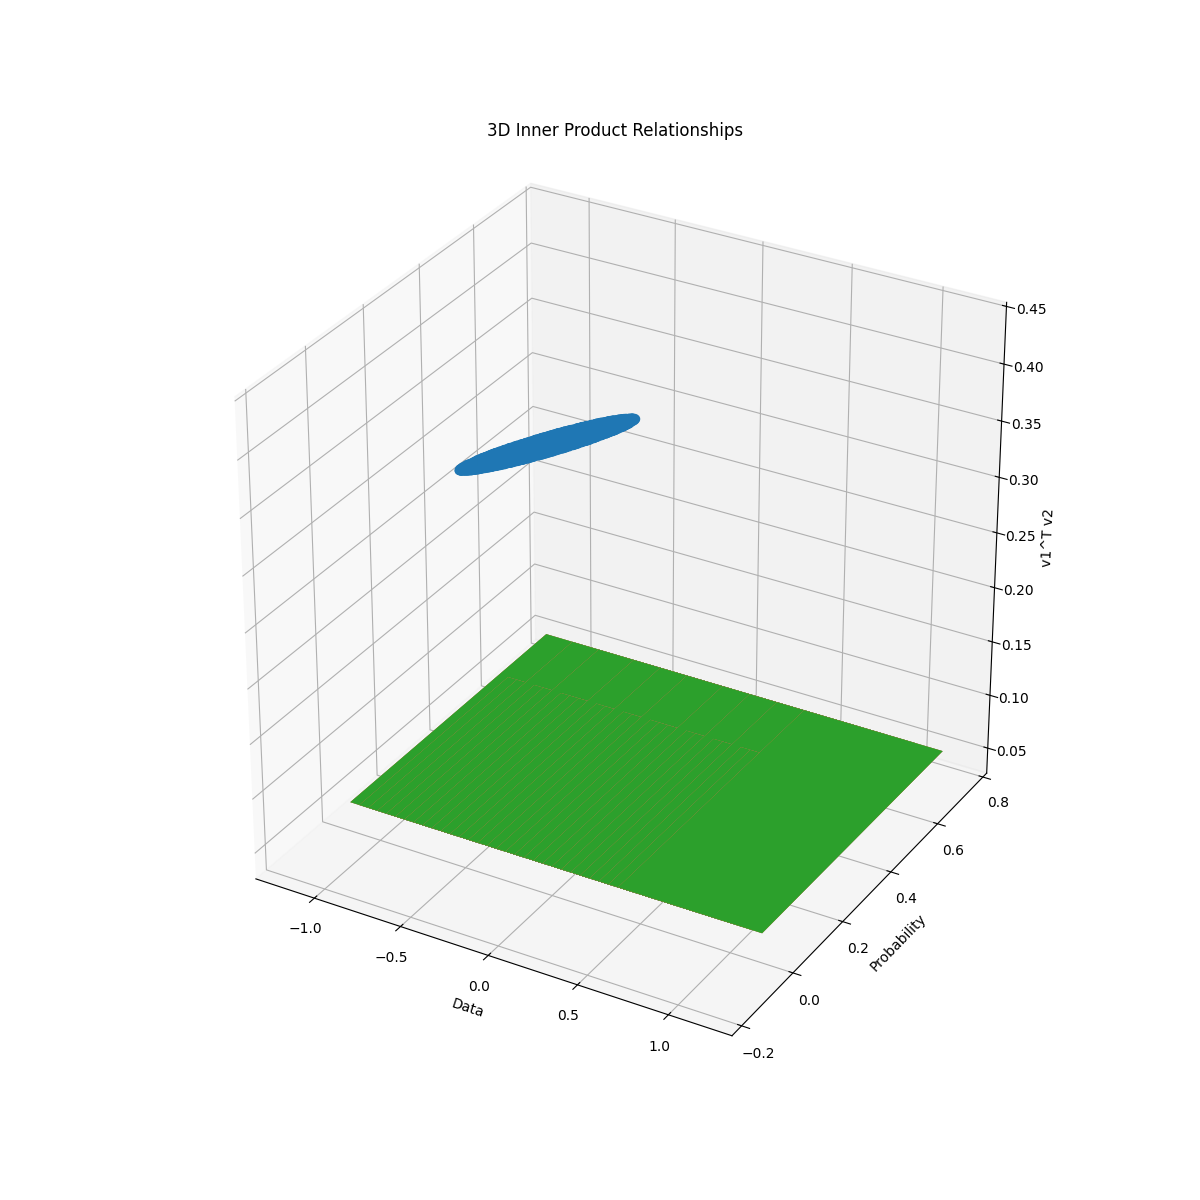

In [637]:
n = 5
k = 3
all_row_sums = []
for _ in range(10000):
    A = np.random.rand(n,n)
    Q, _ = np.linalg.qr(A)
    X = Q[:k, :].T @ Q[:k, :]
    for i in range(X.shape[0]):
        row_sum = np.sum(np.abs(X[i,:])) - np.abs(X[i,i])
        all_row_sums.append(row_sum)

all_row_sums = np.array(all_row_sums)
plt.hist(x, density=True, bins=30)  # density=False would make counts
plt.ylabel('Probability')
plt.xlabel('Data')
plt.show()

In [614]:
results.shape

(10000, 3)

In [591]:
import numpy as np

def verify_vector_pairs(v1, v1_prime, v2, v2_prime):
    """
    Verify properties of the vector pairs:
    1. Orthogonality of [v1;v1'] and [v2;v2']
    2. Norms sum to 1 for each pair
    3. Print vector lengths
    4. Verify v1^T v2 = -v1'^T v2'
    """
    # Convert inputs to numpy arrays if they aren't already
    v1, v1_prime = np.array(v1), np.array(v1_prime)
    v2, v2_prime = np.array(v2), np.array(v2_prime)
    
    # Print lengths
    print(f"||v1|| = {np.linalg.norm(v1):.6f}")
    print(f"||v2|| = {np.linalg.norm(v2):.6f}")
    print(f"||v1'|| = {np.linalg.norm(v1_prime):.6f}")
    print(f"||v2'|| = {np.linalg.norm(v2_prime):.6f}")
    
    # Verify norms sum to 1
    print(f"\n||v1||^2 + ||v1'||^2 = {np.linalg.norm(v1)**2 + np.linalg.norm(v1_prime)**2:.10f}")
    print(f"||v2||^2 + ||v2'||^2 = {np.linalg.norm(v2)**2 + np.linalg.norm(v2_prime)**2:.10f}")
    
    # Verify orthogonality of concatenated vectors
    v1_concat = np.concatenate([v1, v1_prime])
    v2_concat = np.concatenate([v2, v2_prime])
    ortho_product = np.dot(v1_concat, v2_concat)
    print(f"\n[v1;v1']^T [v2;v2'] = {ortho_product:.10f}")
    
    # Verify v1^T v2 = -v1'^T v2'
    prod1 = np.dot(v1, v2)
    prod2 = np.dot(v1_prime, v2_prime)
    print(f"\nv1^T v2 = {prod1:.10f}")
    print(f"v1'^T v2' = {prod2:.10f}")
    print(f"v1^T v2 + v1'^T v2' = {prod1 + prod2:.10f}")
    
    return {
        'orthogonality_satisfied': abs(ortho_product) < 1e-10,
        'norm_sum_v1': np.linalg.norm(v1)**2 + np.linalg.norm(v1_prime)**2,
        'norm_sum_v2': np.linalg.norm(v2)**2 + np.linalg.norm(v2_prime)**2,
        'inner_product_relation': abs(prod1 + prod2) < 1e-10
    }

# Test with example vectors
v1 = np.array([1/np.sqrt(2), 0])
v1_prime = np.array([0, 1/np.sqrt(2)])
v2 = np.array([1/np.sqrt(2) * np.cos(np.pi/3), 1/np.sqrt(2) * np.sin(np.pi/3)])
v2_prime = np.array([-1/np.sqrt(2) * np.sin(np.pi/3), 1/np.sqrt(2) * np.cos(np.pi/3)])

print("Testing example vectors:")
results = verify_vector_pairs(v1, v1_prime, v2, v2_prime)

print("\nVerification results:")
print(f"Orthogonality satisfied: {results['orthogonality_satisfied']}")
print(f"||v1||^2 + ||v1'||^2 = 1: {abs(results['norm_sum_v1'] - 1) < 1e-10}")
print(f"||v2||^2 + ||v2'||^2 = 1: {abs(results['norm_sum_v2'] - 1) < 1e-10}")
print(f"v1^T v2 = -v1'^T v2': {results['inner_product_relation']}")

Testing example vectors:
||v1|| = 0.707107
||v2|| = 0.707107
||v1'|| = 0.707107
||v2'|| = 0.707107

||v1||^2 + ||v1'||^2 = 1.0000000000
||v2||^2 + ||v2'||^2 = 1.0000000000

[v1;v1']^T [v2;v2'] = 0.5000000000

v1^T v2 = 0.2500000000
v1'^T v2' = 0.2500000000
v1^T v2 + v1'^T v2' = 0.5000000000

Verification results:
Orthogonality satisfied: False
||v1||^2 + ||v1'||^2 = 1: True
||v2||^2 + ||v2'||^2 = 1: True
v1^T v2 = -v1'^T v2': False
